Read Data

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "../src/data/san_francisco_listings_details.csv"
df = pd.read_csv(data_path)

# Drop rows without price
df = df.dropna(subset=['price'])

# Focus on short term analysis
df = df[df['minimum_nights'] <= 30]

print("Shape of dataset:", df.shape)

Shape of dataset: (5374, 79)


Select Relevant Features

In [71]:
keep_cols = [
    'name', 'description', 'picture_url','neighbourhood_cleansed', 
    'latitude', 'longitude', 'room_type','accommodates', 'bathrooms', 'bedrooms', 
    'beds', 'amenities', 'price', 'number_of_reviews', 'review_scores_rating'
]

df = df[keep_cols]

print("Shape after column selection:", df.shape)
df.head()


Shape after column selection: (5374, 15)


,name,description,picture_url,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,number_of_reviews,review_scores_rating
0,"Bright, Modern Garden Unit - 1BR/1BTH",Our bright garden unit overlooks a lovely back...,https://a0.muscache.com/pictures/be1bf5ac-a955...,Western Addition,37.77028,-122.43317,Entire home/apt,3,1.0,1.0,2.0,"[""Clothing storage: closet and dresser"", ""Esse...",$157.00,496,4.89
1,Creative Sanctuary,We live in a large Victorian house on a quiet ...,https://a0.muscache.com/pictures/hosting/Hosti...,Bernal Heights,37.74474,-122.42089,Entire home/apt,4,2.0,2.0,2.0,"[""Carbon monoxide alarm"", ""Shampoo"", ""Hair dry...",$250.00,105,4.87
2,female HOST quiet fast internet market parking,Room is on the second floor so it gets a good ...,https://a0.muscache.com/pictures/2cc1fc3d-0ae0...,Outer Mission,37.73077,-122.44827,Private room,1,2.0,1.0,1.0,"[""Dryer"", ""Essentials"", ""Hangers"", ""Backyard"",...",$67.00,90,4.77
4,Historic Alamo Square Victorian,"For creative humans who love art, space, photo...",https://a0.muscache.com/pictures/miso/Hosting-...,Western Addition,37.77377,-122.43614,Entire home/apt,2,1.5,1.0,1.0,"[""Dedicated workspace"", ""Essentials"", ""Hangers...",$527.00,25,4.86
5,Elegant & Cozy w/City views. Private room: Purple,Casa de Paz (House of Peace) is like staying w...,https://a0.muscache.com/pictures/airflow/Hosti...,Bayview,37.71750,-122.39698,Private room,2,1.5,1.0,1.0,"[""Blender"", ""Shared BBQ grill: charcoal"", ""Ess...",$108.00,40,4.97


Preprocess the data

In [72]:
# 1. Preprocess the price column
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['price'] = df['price'].round(0).astype(int)
df = df[df['price'] > 0]

#2. Handle the missing reviews / rooms values
df['no_rating'] = (df['number_of_reviews'] == 0).astype(int)
df['review_scores_rating'].fillna(0, inplace=True)
df = df.dropna(subset=['bathrooms', 'bedrooms', 'beds'])

#3. Modify amenity columns
df['amenity_count'] = df['amenities'].apply(lambda x: len(str(x).split(',')))
df.drop(columns=['amenities'], inplace=True)
df['amenity_count'].describe()

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\cuiha\AppData\Local\Temp\ipykernel_34304\685601437.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\cuiha\AppData\Local\Temp\ipykernel_34304\685601437.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review_scores_rating'].fillna(0, inplace=True)


count    5322.000000
mean       37.079481
std        15.957266
min         1.000000
25%        25.000000
50%        37.000000
75%        48.000000
max        97.000000
Name: amenity_count, dtype: float64

Numeric Features Overview

,count,mean,std,min,25%,50%,75%,max
latitude,5322.0,37.768332,0.023936,37.708480,37.752160,37.773755,37.788393,37.80954
longitude,5322.0,-122.432065,0.027698,-122.510362,-122.444865,-122.424110,-122.411910,-122.36871
accommodates,5322.0,3.291995,2.058633,1.000000,2.000000,2.000000,4.000000,16.00000
bathrooms,5322.0,1.295847,0.679517,0.000000,1.000000,1.000000,1.500000,10.00000
bedrooms,5322.0,1.424840,1.020964,0.000000,1.000000,1.000000,2.000000,11.00000
beds,5322.0,1.802706,1.240551,0.000000,1.000000,1.000000,2.000000,16.00000
number_of_reviews,5322.0,69.005261,129.068229,0.000000,2.000000,13.000000,75.750000,1417.00000
review_scores_rating,5322.0,3.971933,1.848702,0.000000,4.500000,4.870000,4.990000,5.00000
no_rating,5322.0,0.173995,0.379141,0.000000,0.000000,0.000000,0.000000,1.00000
amenity_count,5322.0,37.079481,15.957266,1.000000,25.000000,37.000000,48.000000,97.00000


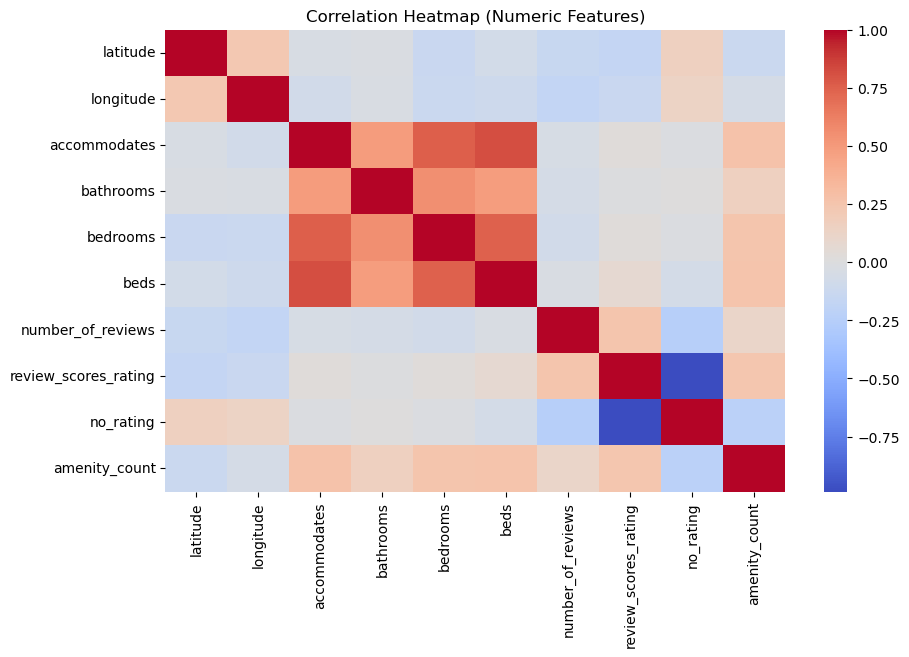

In [73]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = [col for col in numeric_cols if col != 'price']
display(df[numeric_cols].describe().T)

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

Distribution of Prices

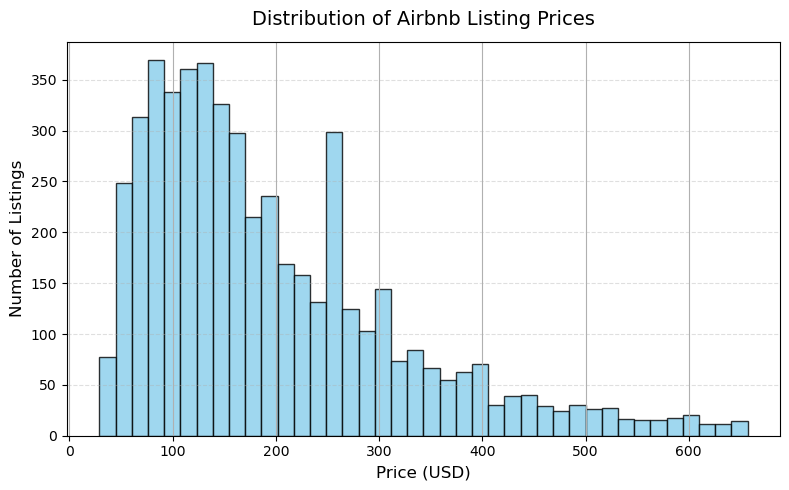

In [85]:
plt.figure(figsize=(8,5))
# Plot the histogram (cap to 95th percentile to avoid outlier distortion)
df[df['price'] <= np.percentile(df['price'], 95)]['price'].hist(
    bins=40,
    color='skyblue',
    edgecolor='black',
    alpha=0.8
)

# Labels and title
plt.title('Distribution of Airbnb Listing Prices', fontsize=14, pad=12)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()